In [6]:
# 02 Baselines
# This notebook establishes baseline performance for the rice leaf disease classification task using a simple machine learning model and a small CNN trained from scratch. These models serve as reference points for comparison with the EfficientNetB0-based approach.

In [7]:
# =========================
# CELL 1: IMPORTS
# =========================
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers, models

from src.data_pipeline import load_dataframes, encode_labels, make_datasets

In [8]:
# =========================
# CELL 2: LOAD DATA
# =========================
import os

train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

y_train, y_val, label_encoder, class_names = encode_labels(train_df, val_df)

print("Classes:", class_names)
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
train_df.head()

Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']
Train shape: (2684, 4)
Val shape: (671, 4)


,filepath,label,split,full_path
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...


In [9]:
# =========================
# CELL 3: SIMPLE IMAGE FEATURE EXTRACTOR
# =========================
IMG_SIZE_BASELINE = (64, 64)

def load_flattened_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_BASELINE)
    img = tf.cast(img, tf.float32) / 255.0
    return tf.reshape(img, [-1]).numpy()

X_train_flat = np.array([load_flattened_image(p) for p in train_df["full_path"] if os.path.exists(p)])
X_val_flat = np.array([load_flattened_image(p) for p in val_df["full_path"] if os.path.exists(p)])

print("Flattened train shape:", X_train_flat.shape)
print("Flattened val shape:", X_val_flat.shape)

Flattened train shape: (2684, 12288)
Flattened val shape: (671, 12288)


In [10]:
# =========================
# CELL 4: PCA FOR FASTER LOGISTIC REGRESSION
# =========================
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca = pca.transform(X_val_flat)

print("PCA train shape:", X_train_pca.shape)
print("PCA val shape:", X_val_pca.shape)

PCA train shape: (2684, 100)
PCA val shape: (671, 100)


In [11]:
# =========================
# CELL 5: LOGISTIC REGRESSION BASELINE
# =========================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_pca, y_train)

lr_pred = lr_model.predict(X_val_pca)

lr_acc = accuracy_score(y_val, lr_pred)
lr_f1 = f1_score(y_val, lr_pred, average="macro")

print("Logistic Regression Accuracy:", round(lr_acc, 4))
print("Logistic Regression Macro-F1:", round(lr_f1, 4))
print(classification_report(y_val, lr_pred, target_names=class_names))

Logistic Regression Accuracy: 0.2429
Logistic Regression Macro-F1: 0.1684
              precision    recall  f1-score   support

   BrownSpot       0.17      0.25      0.20       105
     Healthy       0.44      0.44      0.44       297
       Hispa       0.00      0.00      0.00       113
   LeafBlast       0.03      0.04      0.03       156

    accuracy                           0.24       671
   macro avg       0.16      0.18      0.17       671
weighted avg       0.23      0.24      0.23       671



In [12]:
# =========================
# CELL 6: DATASETS FOR SIMPLE CNN
# =========================
IMG_SIZE_CNN = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image_baseline(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_CNN)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_df["full_path"].values, y_train))
    .shuffle(len(train_df), seed=42, reshuffle_each_iteration=True)
    .map(load_image_baseline, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_df["full_path"].values, y_val))
    .map(load_image_baseline, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [13]:
# =========================
# CELL 7: SIMPLE CNN FROM SCRATCH
# =========================
simple_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

simple_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,764 (366.27 KB)

 Trainable params: 93,764 (366.27 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# =========================
# CELL 8: TRAIN SIMPLE CNN
# =========================
simple_history = simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 392ms/step - accuracy: 0.4393 - loss: 1.2647 - val_accuracy: 0.4292 - val_loss: 1.3403
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 382ms/step - accuracy: 0.5652 - loss: 1.0923 - val_accuracy: 0.2101 - val_loss: 1.9104
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 385ms/step - accuracy: 0.5693 - loss: 1.0753 - val_accuracy: 0.2176 - val_loss: 1.8553
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 385ms/step - accuracy: 0.5853 - loss: 1.0377 - val_accuracy: 0.1610 - val_loss: 1.8323
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 382ms/step - accuracy: 0.6032 - loss: 1.0097 - val_accuracy: 0.1937 - val_loss: 1.7860


In [15]:
# =========================
# CELL 9: EVALUATE SIMPLE CNN
# =========================
simple_probs = simple_cnn.predict(val_ds, verbose=1)
simple_pred = np.argmax(simple_probs, axis=1)

simple_acc = accuracy_score(y_val, simple_pred)
simple_f1 = f1_score(y_val, simple_pred, average="macro")

print("Simple CNN Accuracy:", round(simple_acc, 4))
print("Simple CNN Macro-F1:", round(simple_f1, 4))
print(classification_report(y_val, simple_pred, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step
Simple CNN Accuracy: 0.1937
Simple CNN Macro-F1: 0.1491
              precision    recall  f1-score   support

   BrownSpot       0.17      0.40      0.24       105
     Healthy       0.44      0.30      0.36       297
       Hispa       0.00      0.00      0.00       113
   LeafBlast       0.00      0.00      0.00       156

    accuracy                           0.19       671
   macro avg       0.15      0.17      0.15       671
weighted avg       0.22      0.19      0.20       671



c:\Users\PC\Desktop\Copy-Rice-Leaf-Disease-Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\Desktop\Copy-Rice-Leaf-Disease-Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\Desktop\Copy-Rice-Leaf-Disease-Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

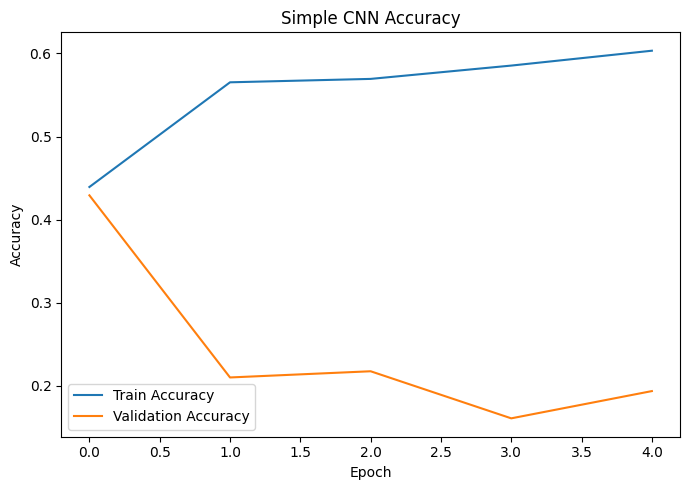

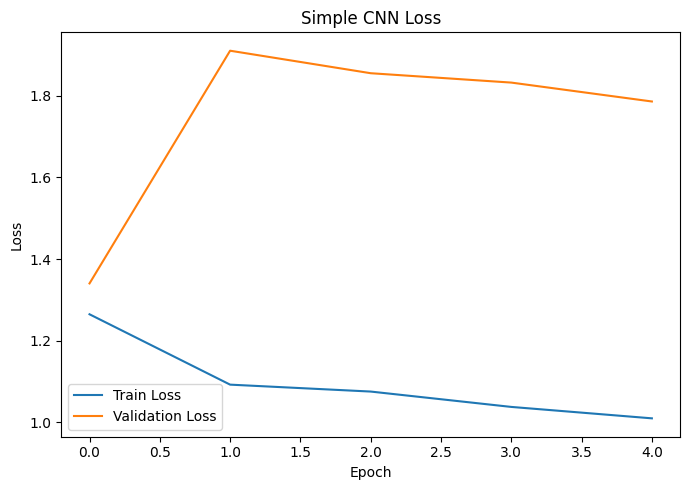

In [16]:
# =========================
# CELL 10: SIMPLE CNN LEARNING CURVES
# =========================
plt.figure(figsize=(7, 5))
plt.plot(simple_history.history["accuracy"], label="Train Accuracy")
plt.plot(simple_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Simple CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(simple_history.history["loss"], label="Train Loss")
plt.plot(simple_history.history["val_loss"], label="Validation Loss")
plt.title("Simple CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# =========================
# CELL 11: BASELINE COMPARISON TABLE
# =========================
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Simple CNN"],
    "Accuracy": [lr_acc, simple_acc],
    "Macro-F1": [lr_f1, simple_f1]
})

baseline_results

,Model,Accuracy,Macro-F1
0,Logistic Regression,0.242921,0.168413
1,Simple CNN,0.193741,0.149061
